In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# --- 1. Define Constants and Paths (ACTION: UPDATE DATA_DIR) ---
IMAGE_SIZE = (224, 224) 
BATCH_SIZE = 32
# ⚠️ UPDATE THIS LINE: Use the absolute path to your main 'copd_images' folder
DATA_DIR = 'C:/Users/DELL/copd_images' 
CLASSES = ['aff', 'normal'] 

# --- 2. Data Augmentation (Training Set) ---
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalization: Scales pixels to [0, 1]
    rotation_range=20,        # Data Augmentation: Creates synthetic images
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    fill_mode='nearest'
)

# --- 3. Validation/Test Data (Only Rescaling/Normalization) ---
val_test_datagen = ImageDataGenerator(rescale=1./255)

# --- 4. Load Data Generators ---
print("1. Loading datasets from directory structure...")
try:
    train_generator = train_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'train'),
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASSES 
    )

    validation_generator = val_test_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'validation'),
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=CLASSES
    )
    
    test_generator = val_test_datagen.flow_from_directory(
        os.path.join(DATA_DIR, 'test'),
        target_size=IMAGE_SIZE,
        batch_size=1, 
        class_mode='binary',
        shuffle=False, 
        classes=CLASSES
    )
    
    # Final Confirmation
    print(f"\n✅ Preprocessing complete. Training samples: {train_generator.samples}")
    print(f"   Validation samples: {validation_generator.samples}")
    print(f"   Test samples: {test_generator.samples}")

except Exception as e:
    print(f"🛑 FATAL ERROR: An unexpected error occurred during loading. {e}")
    

1. Loading datasets from directory structure...
Found 1362 images belonging to 2 classes.
Found 238 images belonging to 2 classes.
Found 295 images belonging to 2 classes.

✅ Preprocessing complete. Training samples: 1362
   Validation samples: 238
   Test samples: 295


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam # Import the Adam optimizer


In [13]:
import numpy as np

# Your correctly calculated class weights
class_weights_dict = {0: 1.3915094339622642, 1: 0.7804232804232805}

def weighted_generator(generator):
    """Wraps an existing Keras generator to yield sample weights."""
    while True:
        # Get the next batch of data (X) and labels (y)
        X, y = next(generator)
        
        # Initialize an array of ones for sample weights
        sample_weights = np.ones(y.shape[0])
        
        # Apply the calculated weights based on the label (0 or 1)
        for i in range(y.shape[0]):
            label = int(y[i])
            sample_weights[i] = class_weights_dict[label]
        
        # The generator must now yield X, y, and sample_weights
        yield X, y, sample_weights

# --- Create the new weighted training generator ---
weighted_train_generator = weighted_generator(train_generator)


In [5]:
IMAGE_SIZE = (224, 224) 

# --- 1. Model Architecture - Transfer Learning (ResNet-50) ---
print("\n--- Starting Model Build and Training ---")
print("1. Setting up Transfer Learning Model (ResNet-50)...")



--- Starting Model Build and Training ---
1. Setting up Transfer Learning Model (ResNet-50)...


In [18]:
# Load the Pre-trained Base Model
base_model = ResNet50(
    weights='imagenet',       # Load weights pre-trained on ImageNet
    include_top=False,        # Exclude original classification head
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
)

# Freeze the Base Layers
for layer in base_model.layers:
    layer.trainable = False

# Add Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x) # Condense feature maps
x = Dense(1024, activation='relu')(x) 
x = Dropout(0.5)(x) # Dropout layer to mitigate overfitting
predictions = Dense(1, activation='sigmoid')(x) # Single output node for P(affected)

# Final Model Definition and Compilation
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.0001), # Use a low learning rate for Transfer Learning
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # AUC is essential for imbalanced medical data
)
print("   Model compiled successfully.")

# --- 2. Training and Optimization ---

# Define Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', 
    patience=5,             # Stop if val_auc doesn't improve for 5 epochs
    mode='max', 
    restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_copd_image_model.h5', 
    monitor='val_auc', 
    save_best_only=True, 
    mode='max',
    verbose=1
)



   Model compiled successfully.


In [14]:
print("\n2. Starting Model Training...")
# --- UPDATE Model Training (model.fit) ---

# We use the new weighted generator here
history = model.fit(
    weighted_train_generator, # <-- USE THE NEW GENERATOR HERE
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=25, 
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, checkpoint]
    # **REMOVED** class_weight=class_weights_dict 
)
print("\n✅ Training complete. Proceed to Step 3 for evaluation and probability extraction.")



2. Starting Model Training...
Epoch 1/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5197 - auc: 0.5081 - loss: 0.7494
Epoch 1: val_auc improved from None to 0.97776, saving model to best_copd_image_model.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.5409 - auc: 0.5272 - loss: 0.7249 - val_accuracy: 0.6250 - val_auc: 0.9778 - val_loss: 0.6124
Epoch 2/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6136 - auc: 0.5584 - loss: 0.6967
Epoch 2: val_auc improved from 0.97776 to 0.97840, saving model to best_copd_image_model.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.6135 - auc: 0.5996 - loss: 0.6735 - val_accuracy: 0.7857 - val_auc: 0.9784 - val_loss: 0.5752
Epoch 3/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6157 - auc: 0.6133 - loss: 0.6734
Epoch 3: val_auc did not improve from 0.97840
42/42 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.6203 - auc: 0.6226 - loss: 0.6624 - val_accuracy: 0.8705 - val_auc: 0.9774 - val_loss: 0.5409
Epoch 4/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6707 - auc: 0.6766 - loss: 0.6257
Epoch 4: val_auc did not improve from 0.97840
42/42 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6767 - auc: 0.6978 - loss: 0.6173 - val_accuracy: 0.8973 - val_auc: 0.9783 - val_loss: 0.5114
Epoch 5/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6595 - auc: 0.6801 - loss: 0.6209
Epoch 5: val_auc improved from 0.97840 to 0.97885, saving model to best_copd_image_model.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6684 - auc: 0.7098 - loss: 0.6093 - val_accuracy: 0.9152 - val_auc: 0.9789 - val_loss: 0.5038
Epoch 6/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7004 - auc: 0.7491 - loss: 0.5928
Epoch 6: val_auc improved from 0.97885 to 0.98223, saving model to best_copd_image_model.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7233 - auc: 0.7556 - loss: 0.5829 - val_accuracy: 0.8616 - val_auc: 0.9822 - val_loss: 0.4560
Epoch 7/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7278 - auc: 0.7883 - loss: 0.5794
Epoch 7: val_auc improved from 0.98223 to 0.98252, saving model to best_copd_image_model.h5


42/42 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7286 - auc: 0.7962 - loss: 0.5693 - val_accuracy: 0.9598 - val_auc: 0.9825 - val_loss: 0.4366
Epoch 8/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8007 - auc: 0.8279 - loss: 0.5281
Epoch 8: val_auc did not improve from 0.98252
42/42 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7850 - auc: 0.8373 - loss: 0.5281 - val_accuracy: 0.8482 - val_auc: 0.9787 - val_loss: 0.4517
Epoch 9/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7308 - auc: 0.8420 - loss: 0.5324
Epoch 9: val_auc did not improve from 0.98252
42/42 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7586 - auc: 0.8455 - loss: 0.5216 - val_accuracy: 0.9018 - val_auc: 0.9788 - val_loss: 0.3920
Epoch 10/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7812 - auc: 0.8571 - loss: 0.5167
Epoch 10: val_auc did not improve from 0.98252
42/42 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7820 - auc: 0.8478 - loss: 0.5184 - val_accuracy: 0.9598 - val_auc: 0.9797 

42/42 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8195 - auc: 0.8759 - loss: 0.4895 - val_accuracy: 0.9598 - val_auc: 0.9826 - val_loss: 0.3350
Epoch 13/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8320 - auc: 0.8923 - loss: 0.4652
Epoch 13: val_auc did not improve from 0.98257
42/42 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8368 - auc: 0.8886 - loss: 0.4609 - val_accuracy: 0.9509 - val_auc: 0.9795 - val_loss: 0.3237
Epoch 14/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8090 - auc: 0.8834 - loss: 0.4839
Epoch 14: val_auc did not improve from 0.98257
42/42 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8113 - auc: 0.8840 - loss: 0.4737 - val_accuracy: 0.9598 - val_auc: 0.9795 - val_loss: 0.3129
Epoch 15/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8549 - auc: 0.9095 - loss: 0.4289
Epoch 15: val_auc did not improve from 0.98257
42/42 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8556 - auc: 0.9074 - loss: 0.4328 - val_accuracy: 0.9554 - val_auc: 0.9

In [15]:
# --- 1. Load the Best Model Weights ---
# This ensures you are evaluating the best version saved by the ModelCheckpoint callback
model.load_weights('best_copd_image_model.h5')

# --- 2. Final Evaluation on the Test Set ---
print("\n--- 1. Final Model Evaluation ---")
# Ensure 'test_generator' (from your data loading step) is still defined
test_results = model.evaluate(test_generator, steps=test_generator.samples)
loss, acc, auc_score = test_results[0], test_results[1], test_results[2]

print("-----------------------------------------------------")
print(f"Final Image Model Test Accuracy: {acc:.4f}")
print(f"Final Image Model Test AUC-ROC: {auc_score:.4f}")

# --- 3. Probability Extraction (P_image) ---
print("\n--- 2. Extracting Probabilities for Ensemble Fusion ---")
# Predicts the probability of the image being 'affected' (class 0, based on your class order)
P_image_raw = model.predict(test_generator)
P_image = P_image_raw.flatten() 

print(f"P_image Array Shape: {P_image.shape}")
print("✅ Model 2 Complete: Probabilities extracted and ready for fusion.")



--- 1. Final Model Evaluation ---
295/295 ━━━━━━━━━━━━━━━━━━━━ 55s 186ms/step - accuracy: 0.8644 - auc: 0.9418 - loss: 0.4194
-----------------------------------------------------
Final Image Model Test Accuracy: 0.8644
Final Image Model Test AUC-ROC: 0.9418

--- 2. Extracting Probabilities for Ensemble Fusion ---
295/295 ━━━━━━━━━━━━━━━━━━━━ 59s 187ms/step
P_image Array Shape: (295,)
✅ Model 2 Complete: Probabilities extracted and ready for fusion.


In [16]:
import numpy as np

# --- 1. Reset the Generator ---
# IMPORTANT: This ensures the test generator is at the start and runs in the correct order.
test_generator.reset()

# --- 2. Extract the True Labels ---
# The .labels attribute of the test_generator stores the true labels (0s and 1s) 
# corresponding to the sequence of images it loaded.
y_true_labels = test_generator.labels

print(f"✅ Extracted {len(y_true_labels)} true labels (y_true_labels).")


✅ Extracted 295 true labels (y_true_labels).


In [17]:
from sklearn.metrics import classification_report
import numpy as np

# --- FIX: Retrieve the True Labels ---
# Assuming 'test_generator' is still defined from the data loading step
test_generator.reset() 
y_true_labels = test_generator.labels 

# Assuming P_image (the probability array) is already defined from model.predict()
# If P_image is not defined, run the model.predict() line first!
# P_image = model.predict(test_generator).flatten() 

# Convert probabilities to final predictions (0 or 1) using a 0.5 threshold
y_pred_image = (P_image > 0.5).astype(int)

# Generate the detailed report (all values are percentage-based)
report = classification_report(y_true_labels, y_pred_image, 
                               target_names=['aff (0)', 'normal (1)'], 
                               output_dict=True)

print("\n--- DETAILED PERFORMANCE PERCENTAGE REPORT ---")
# Print overall metrics
print(f"Overall Accuracy: {report['accuracy'] * 100:.2f}%")
print(f"Normal Class F1-Score: {report['normal (1)']['f1-score'] * 100:.2f}%")
print(f"Affected Class F1-Score: {report['aff (0)']['f1-score'] * 100:.2f}%")
print("\nFull Classification Report:\n", classification_report(y_true_labels, y_pred_image, target_names=['aff (0)', 'normal (1)']))



--- DETAILED PERFORMANCE PERCENTAGE REPORT ---
Overall Accuracy: 86.44%
Normal Class F1-Score: 89.74%
Affected Class F1-Score: 80.00%

Full Classification Report:
               precision    recall  f1-score   support

     aff (0)       0.85      0.75      0.80       106
  normal (1)       0.87      0.93      0.90       189

    accuracy                           0.86       295
   macro avg       0.86      0.84      0.85       295
weighted avg       0.86      0.86      0.86       295



<Figure size 700x700 with 0 Axes>

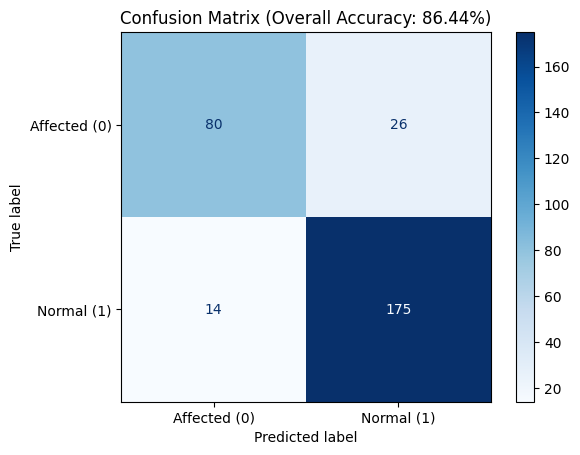

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_true_labels (true labels) and y_pred_image (predictions 0/1) are defined.

# Calculate the Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_image)
class_labels = ['Affected (0)', 'Normal (1)']

# Display the matrix visually
plt.figure(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Confusion Matrix (Overall Accuracy: {np.mean(y_true_labels == y_pred_image)*100:.2f}%)')
plt.grid(False) # Turn off grid lines inside the matrix plot
plt.show()


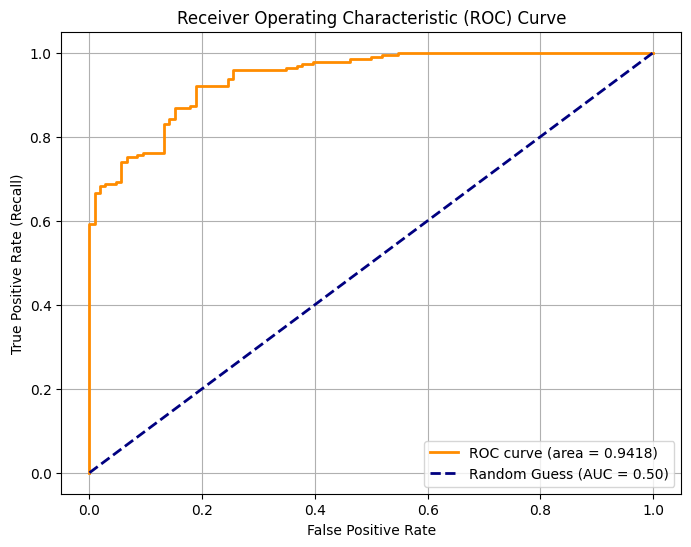

In [20]:
from sklearn.metrics import roc_curve, auc

# Assuming P_image (probability array) and y_true_labels are defined.

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_true_labels, P_image)
roc_auc = auc(fpr, tpr)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Guess (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


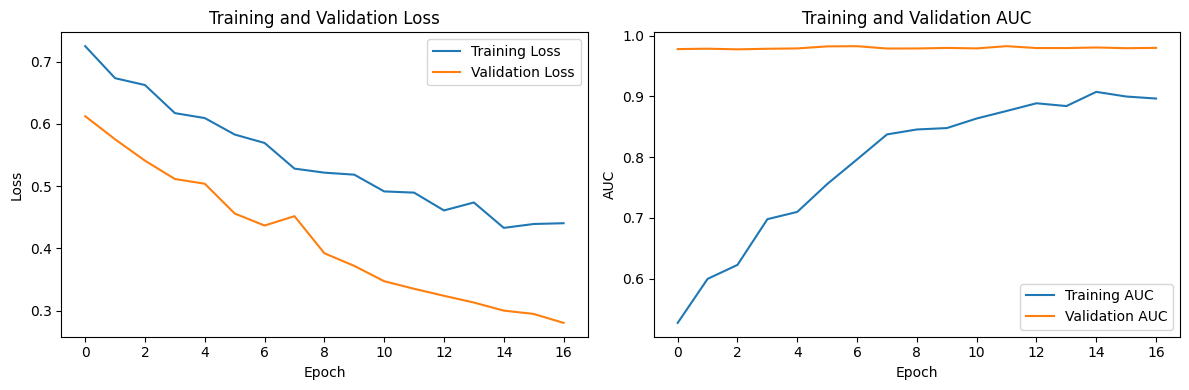

In [21]:
# Assuming 'history' object from your model.fit() call is still defined.
if 'history' in locals() and history is not None:
    plt.figure(figsize=(12, 4))

    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot 2: AUC
    plt.subplot(1, 2, 2)
    plt.plot(history.history['auc'], label='Training AUC')
    plt.plot(history.history['val_auc'], label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Training history object ('history') not found. Please ensure you ran the model.fit() cell last.")
    